# Platform-only opinion-dynamics scenario

This notebook is an executed observation layer for the tested `opinion_model.scenarios.platform` package. It examines the connected effect of uniform out-of-network availability, finite attention, and exposure-driven network adaptation. It does not reimplement the mechanisms, separate their causal contributions, calibrate their parameters, or introduce opinion leaders.

In [1]:
from dataclasses import asdict, replace
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.mpl-cache'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from opinion_model.scenarios.platform import (
    initialize_platform,
    load_platform_experiment_config,
    platform_diagnostic_frames,
    run_platform_condition,
    run_platform_experiment,
    final_condition_metrics,
    summarize_final_conditions,
)
from opinion_model.shared import RandomStreams

sns.set_theme(style='whitegrid', context='notebook')
experiment = load_platform_experiment_config(PROJECT_ROOT / 'configs' / 'platform.toml')
config = experiment.platform_case
print(f'Loaded {experiment.experiment_id!r}: {len(experiment.seeds)} seeds, {config.simulation.rounds} rounds each.')

Loaded 'platform': 10 seeds, 50 rounds each.


## Resolved exploratory configuration

The values below are inherited working assumptions from the integrated baseline. They are inputs to a mechanism-level exploration, not fitted or empirically validated estimates.

In [2]:
configuration = pd.json_normalize(asdict(experiment), sep='.').T
configuration.columns = ['value']
configuration

,value
experiment_id,platform
status,exploratory
seeds,"(20260910, 20260911, 20260912, 20260913, 20260..."
extremism_threshold,0.8
platform_case.simulation.agent_count,500
platform_case.simulation.rounds,50
platform_case.simulation.seed,20260910
platform_case.simulation.initial_mean,0.5
platform_case.simulation.initial_concentration,4.0
platform_case.simulation.base_origination_probability,0.1


## Matched initialization and rounds 1–5 close reading

Initialization draws the same directed Barabási–Albert network and ordinary beliefs as the matched null scenario. The diagnostic run then retains every availability, capacity, exposure, evidence, and network decision needed to reconstruct the first five synchronous transitions.

In [3]:
initialization = initialize_platform(
    config,
    RandomStreams(experiment.seeds[0]).initialization(),
)
initial_state = initialization.state
initial_edges = sum(len(values) for values in initial_state.network.neighbors_by_agent.values())
initial_beliefs = np.array([state.belief.signed_mean for state in initial_state.agents.values()])
pd.Series({
    'seed': experiment.seeds[0],
    'agents': len(initial_state.agents),
    'directed_edges': initial_edges,
    'mean_following_degree': initial_edges / len(initial_state.agents),
    'mean_signed_belief': initial_beliefs.mean(),
    'mean_absolute_belief': np.abs(initial_beliefs).mean(),
})

seed                     2.026091e+07
agents                   5.000000e+02
directed_edges           1.491000e+03
mean_following_degree    2.982000e+00
mean_signed_belief       2.640982e-02
mean_absolute_belief     3.875686e-01
dtype: float64

In [4]:
diagnostic_config = replace(
    config,
    simulation=replace(config.simulation, seed=experiment.seeds[0], rounds=5),
)
diagnostic_run = run_platform_condition(
    diagnostic_config,
    extremism_threshold=experiment.extremism_threshold,
)
diagnostics = platform_diagnostic_frames(
    diagnostic_run.simulation_result,
    diagnostic_config,
    last_round=5,
)
pd.DataFrame({'table': diagnostics.keys(), 'rows': [len(frame) for frame in diagnostics.values()]})

,table,rows
0,states,3000
1,origination,2500
2,messages,257
3,exposures,5870
4,aggregates,2500
5,network,9062
6,selection_decisions,128243
7,network_decisions,5870
8,transitions,2500


In [5]:
display(diagnostics['transitions'].head(10))
display(diagnostics['selection_decisions'].query('consumer_id == 0').head(12))
display(diagnostics['network_decisions'].head(12))

,round,agent_id,a_before,b_before,origination_probability,p_support_at_origination,did_originate,originated_stance,candidate_pool_size,capacity_binding,...,formation_opportunity_count,accepted_addition_count,dissolution_opportunity_count,accepted_removal_count,following_degree_before,following_degree_after,a_after,b_after,signed_mean_before,signed_mean_after
0,1,0,2.234959,1.765041,0.1,0.603125,False,NaN,2,False,...,1,0,1,0,21,21,2.334959,1.865041,0.117479,0.111885
1,1,1,1.628735,2.371265,0.1,0.339366,False,NaN,3,False,...,3,1,0,0,6,7,1.728735,2.571265,-0.185633,-0.195937
2,1,2,2.198939,1.801061,0.1,0.587553,False,NaN,0,False,...,0,0,0,0,4,4,2.198939,1.801061,0.099469,0.099469
3,1,3,2.102667,1.897333,0.1,0.545413,False,NaN,1,False,...,1,0,0,0,8,8,2.102667,1.997333,0.051333,0.025691
4,1,4,3.105874,0.894126,0.1,0.900406,False,NaN,4,False,...,1,0,3,0,37,37,3.305874,1.094126,0.552937,0.502670
5,1,5,1.038259,2.961741,0.1,0.134997,False,NaN,6,False,...,2,0,4,0,19,19,1.138259,3.461741,-0.480870,-0.505105
6,1,6,2.367183,1.632817,0.1,0.658951,False,NaN,1,False,...,1,0,0,0,12,12,2.367183,1.732817,0.183591,0.154723
7,1,7,0.342525,3.657475,0.1,0.017632,True,-1.0,4,False,...,3,0,1,0,19,19,0.442525,3.957475,-0.828738,-0.798852
8,1,8,1.601686,2.398314,0.1,0.328280,False,NaN,7,False,...,4,0,3,1,15,14,1.701686,2.998314,-0.199157,-0.275878
9,1,9,1.831995,2.168005,0.1,0.425915,False,NaN,4,False,...,4,0,0,0,6,6,2.031995,2.368005,-0.084003,-0.076366


,round,consumer_id,message_id,producer_id,message_stance,channel,availability_probability,availability_draw,available,candidate_pool_size,capacity_binding,retained
0,1,0,r1:a7,7,-1,tie,1.00,NaN,True,2,False,True
1,1,0,r1:a16,16,-1,out_of_network,0.04,0.589468,False,2,False,False
2,1,0,r1:a39,39,1,out_of_network,0.04,0.291489,False,2,False,False
3,1,0,r1:a44,44,1,out_of_network,0.04,0.733114,False,2,False,False
4,1,0,r1:a52,52,1,out_of_network,0.04,0.190658,False,2,False,False
5,1,0,r1:a62,62,1,out_of_network,0.04,0.661939,False,2,False,False
6,1,0,r1:a63,63,-1,out_of_network,0.04,0.750556,False,2,False,False
7,1,0,r1:a67,67,-1,out_of_network,0.04,0.509189,False,2,False,False
8,1,0,r1:a79,79,1,out_of_network,0.04,0.680405,False,2,False,False
9,1,0,r1:a86,86,1,out_of_network,0.04,0.200831,False,2,False,False


,round,consumer_id,producer_id,action,following_degree,normalized_degree,support_probability,message_stance,alignment,probability,random_draw,accepted
0,1,0,7,untie,21,0.042084,0.603125,-1,-0.206249,0.053642,0.068757,False
1,1,0,277,tie,21,0.042084,0.603125,1,0.206249,0.011906,0.225214,False
2,1,1,63,tie,6,0.012024,0.339366,-1,0.321269,0.014395,0.001457,True
3,1,1,79,tie,6,0.012024,0.339366,1,-0.321269,0.007159,0.492292,False
4,1,1,156,tie,6,0.012024,0.339366,-1,0.321269,0.014395,0.589715,False
5,1,3,465,tie,8,0.016032,0.545413,-1,-0.090826,0.009122,0.646779,False
6,1,4,39,untie,37,0.074148,0.900406,1,0.800811,0.019720,0.241158,False
7,1,4,93,untie,37,0.074148,0.900406,1,0.800811,0.019720,0.070625,False
8,1,4,147,tie,37,0.074148,0.900406,-1,-0.800811,0.003701,0.593997,False
9,1,4,199,untie,37,0.074148,0.900406,-1,-0.800811,0.104644,0.332091,False


## Ten-seed, 50-round platform experiment

There is one platform condition per seed. The retained comparison is across matched random realizations; cross-scenario contrasts are deferred until all branches are aligned to reviewed revisions.

In [6]:
round_metrics = run_platform_experiment(experiment)
final_metrics = final_condition_metrics(round_metrics)
final_summary = summarize_final_conditions(final_metrics)
display(final_summary.T)
display(final_metrics[['seed', 'mean_signed_belief', 'mean_absolute_belief', 'edge_count', 'homophily_ratio']])

,0
condition,platform
run_count,10
mean_signed_belief_mean,-0.055001
mean_signed_belief_std,0.092388
mean_absolute_belief_mean,0.142182
mean_absolute_belief_std,0.020789
extremist_ratio_mean,0.0
extremist_ratio_std,0.0
exposure_count_mean,1161.8
exposure_count_std,91.11019


,seed,mean_signed_belief,mean_absolute_belief,edge_count,homophily_ratio
0,20260910,0.053246,0.126846,1712,0.613902
1,20260911,-0.063648,0.129316,1772,0.628668
2,20260912,-0.068945,0.127082,1737,0.603915
3,20260913,-0.117024,0.143992,1720,0.746512
4,20260914,-0.119676,0.150214,1723,0.731863
5,20260915,-0.078535,0.130257,1717,0.649388
6,20260916,0.037151,0.120915,1709,0.612639
7,20260917,0.110356,0.149364,1779,0.724002
8,20260918,-0.181494,0.191649,1735,0.866859
9,20260919,-0.121441,0.152183,1717,0.719278


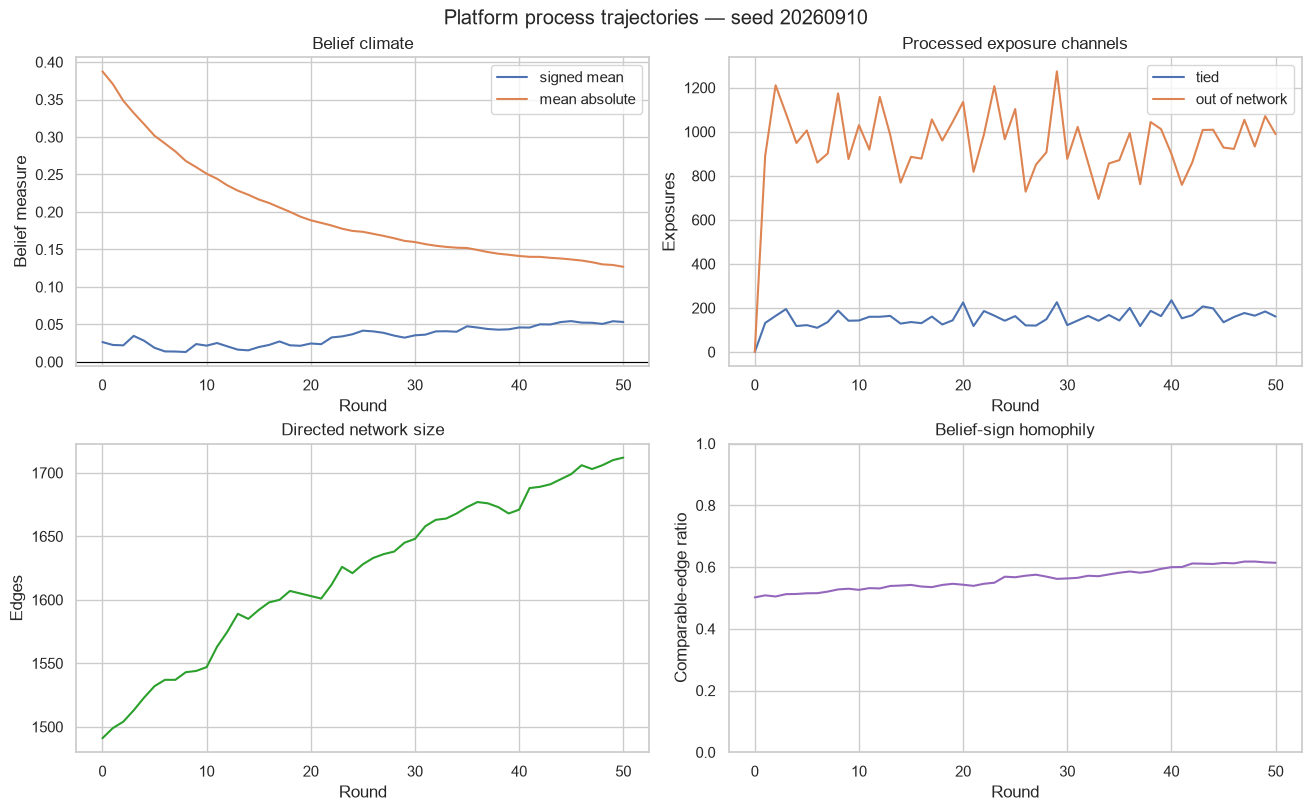

In [7]:
inspected = round_metrics.query('seed == @experiment.seeds[0]').sort_values('round')
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes[0, 0].plot(inspected['round'], inspected['mean_signed_belief'], label='signed mean')
axes[0, 0].plot(inspected['round'], inspected['mean_absolute_belief'], label='mean absolute')
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set(title='Belief climate', xlabel='Round', ylabel='Belief measure')
axes[0, 0].legend()
axes[0, 1].plot(inspected['round'], inspected['tied_exposure_count'], label='tied')
axes[0, 1].plot(inspected['round'], inspected['out_of_network_exposure_count'], label='out of network')
axes[0, 1].set(title='Processed exposure channels', xlabel='Round', ylabel='Exposures')
axes[0, 1].legend()
axes[1, 0].plot(inspected['round'], inspected['edge_count'], color='tab:green')
axes[1, 0].set(title='Directed network size', xlabel='Round', ylabel='Edges')
axes[1, 1].plot(inspected['round'], inspected['homophily_ratio'], color='tab:purple')
axes[1, 1].set(title='Belief-sign homophily', xlabel='Round', ylabel='Comparable-edge ratio', ylim=(0, 1))
fig.suptitle(f'Platform process trajectories — seed {experiment.seeds[0]}')
plt.show()

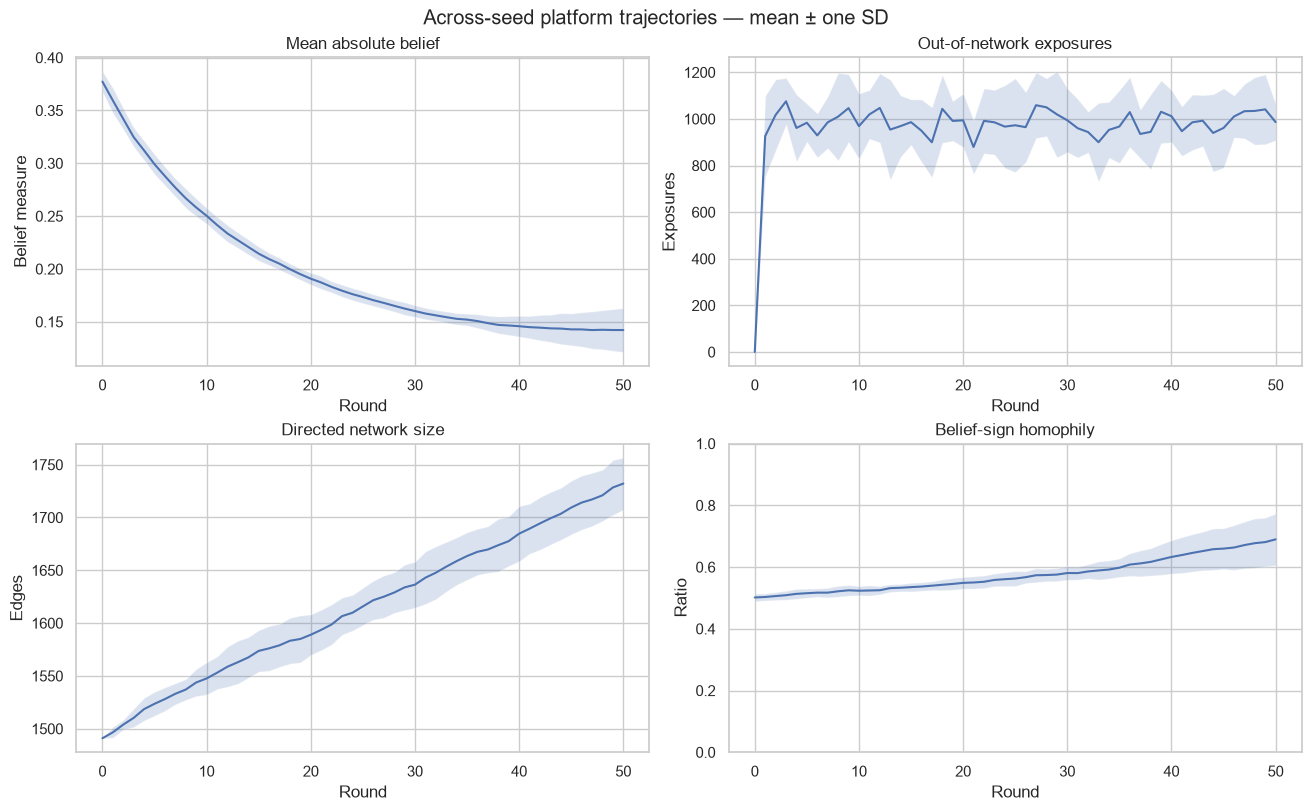

In [8]:
trajectory = round_metrics.groupby('round').agg(
    mean_absolute_mean=('mean_absolute_belief', 'mean'),
    mean_absolute_std=('mean_absolute_belief', 'std'),
    edge_mean=('edge_count', 'mean'),
    edge_std=('edge_count', 'std'),
    homophily_mean=('homophily_ratio', 'mean'),
    homophily_std=('homophily_ratio', 'std'),
    out_reach_mean=('out_of_network_exposure_count', 'mean'),
    out_reach_std=('out_of_network_exposure_count', 'std'),
).reset_index()
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
panels = [
    ('mean_absolute_mean', 'mean_absolute_std', 'Mean absolute belief', 'Belief measure'),
    ('out_reach_mean', 'out_reach_std', 'Out-of-network exposures', 'Exposures'),
    ('edge_mean', 'edge_std', 'Directed network size', 'Edges'),
    ('homophily_mean', 'homophily_std', 'Belief-sign homophily', 'Ratio'),
]
for axis, (mean_col, std_col, title, ylabel) in zip(axes.flat, panels):
    x = trajectory['round'].to_numpy()
    mean = trajectory[mean_col].to_numpy()
    std = trajectory[std_col].fillna(0).to_numpy()
    axis.plot(x, mean)
    axis.fill_between(x, mean - std, mean + std, alpha=0.2)
    axis.set(title=title, xlabel='Round', ylabel=ylabel)
axes[1, 1].set_ylim(0, 1)
fig.suptitle('Across-seed platform trajectories — mean ± one SD')
plt.show()

## Executable scientific-boundary checks

These checks establish implementation consistency and reconstructability. They do not constitute empirical validation.

In [9]:
selection = diagnostics['selection_decisions']
network = diagnostics['network_decisions']
transitions = diagnostics['transitions']
assert not hasattr(config, 'opinion_leader')
assert (selection['consumer_id'] != selection['producer_id']).all()
assert selection.loc[selection['channel'].eq('tie'), 'availability_probability'].eq(1.0).all()
assert selection.loc[selection['channel'].eq('out_of_network'), 'availability_probability'].eq(config.platform.out_of_network_availability_probability).all()
assert (~selection['retained'] | selection['available']).all()
assert selection.groupby(['round', 'consumer_id'])['retained'].sum().le(config.simulation.consumption_capacity).all()
assert network['accepted'].eq(network['random_draw'] < network['probability']).all()
assert np.allclose(transitions['a_after'], transitions['a_before'] + transitions['weighted_support'])
assert np.allclose(transitions['b_after'], transitions['b_before'] + transitions['weighted_oppose'])
for _, seed_frame in round_metrics.sort_values(['seed', 'round']).groupby('seed'):
    prior_edges = seed_frame['edge_count'].shift(1)
    expected_edges = prior_edges + seed_frame['accepted_addition_count'] - seed_frame['accepted_removal_count']
    assert seed_frame.loc[seed_frame['round'].gt(0), 'edge_count'].eq(expected_edges[seed_frame['round'].gt(0)]).all()
assert len(final_metrics) == len(experiment.seeds)
print('All notebook boundary and reconstruction checks passed.')

All notebook boundary and reconstruction checks passed.


## Interpretation boundary

The observed trajectories describe the connected exploratory platform scenario at the configured values. A `platform − null` comparison would estimate the joint package of out-of-network reach, attention competition, and rewiring. Because `ρ = 0` does not disable dissolution of existing ties, the current platform family has no one-parameter full null setting. Separate contribution claims require explicitly designed ablations rather than reinterpretation of this run.